# Capítulo 4 — Análisis de regímenes

**Pregunta central.** ¿Las conclusiones de los Capítulos 1–3 — el ranking entre **MinVar** y **CVaR**, el papel del *sleeve* de crypto y la robustez en *stress windows* — se sostienen de forma homogénea en el tiempo, o están condicionadas por el **estado de mercado**?

Este capítulo es **diagnóstico**, no predictivo. Particionamos la historia en regímenes estimados por un **HMM gaussiano de 2 estados** sobre features de volatilidad, drawdown, correlaciones y momentum, y luego *condicionamos* las métricas ya producidas en los capítulos previos sobre esas etiquetas.

Importante: las etiquetas se derivan de un **fit completo en muestra (in-sample)** para caracterizar heterogeneidad histórica. No son señales operativas ni inferencia causal.

Trabajamos sobre los CSV ya generados por `scripts/run_regime_analysis.py` en `data/processed/regime_analysis/` y por el bloque de tail-risk en `data/processed/tail_risk/`. En este cuaderno analizamos únicamente outputs existentes para mantener consistencia metodológica con Chapters 1–3.

---

**Estrategias comparadas (display names).**

| Identificador interno | Display |
|---|---|
| `minvar_baseline_ch1` | MinVar (baseline) |
| `minvar_no_crypto_control` | MinVar (sin crypto) |
| `cvar_baseline` | CVaR (baseline) |
| `cvar_no_crypto_control` | CVaR (sin crypto) |


## 1. Por qué analizar regímenes después de CVaR y stress windows

Los Capítulos 1–3 dejaron tres resultados agregados:

1. **MinVar (baseline)** y **CVaR (baseline)** producen métricas *full-sample* muy parecidas en términos de Sharpe y MaxDD; las diferencias eran del orden del ruido estadístico (Capítulo 2 — bootstrap).
2. La diferencia entre **baseline** y **sin crypto** existe pero es modesta y depende del periodo.
3. En las *stress windows* del Capítulo 3 (COVID, 2022 rates / stock-bond, 2022 crypto), el ranking entre estrategias **no es estable**: cada ventana premia a una variante distinta.

Esos hallazgos son consistentes con una idea simple: **las métricas full-sample mezclan estados de mercado heterogéneos**. Un Sharpe agregado de 1.0 puede ser la media ponderada de un régimen tranquilo con Sharpe 1.2 y uno estresado con Sharpe 0.6, y el peso relativo de ambos en muestra puede sesgar las conclusiones.

Este capítulo no resuelve esa heterogeneidad — la **describe**. La pregunta no es *qué régimen viene*, sino *si los resultados que ya reportamos esconden estructura por régimen que cambie su lectura económica*.

> **Qué responde esta sección.** Por qué ampliar el análisis condicionando por estado.
> **Qué evidencia usa.** Recordatorio de las conclusiones agregadas previas, no nueva evidencia.
> **Lectura.** El régimen es una variable de control, no una señal.
> **Límite.** No se infiere nada predictivo a partir de aquí.


## 2. Metodología de features y detección de regímenes

**Features.** Construidas en `src/regime_features.py` y materializadas en `regime_features.csv`. Tres familias, todas calculadas en ventanas largas para suavizar ruido diario:

- **Volatilidad realizada** (anualizada, std de log-returns, ventana 63 días) sobre `SPY` y `BTC-USD`.
- **Drawdown rodante** (máx. caída desde pico, ventana 126 días) sobre `SPY` y `BTC-USD`.
- **Correlaciones rodantes** (Pearson, ventana 126 días) entre `SPY–TLT`, `SPY–BTC-USD`, `BTC-USD–ETH-USD`.
- **Momentum** (retorno acumulado, ventana 126 días) sobre `SPY`, `BTC-USD`, `TLT`.

Las features se estandarizan (z-score) antes de ajustar el modelo. El primer tramo con NaN por *warm-up* se elimina; el panel resultante cubre **2018-03-06 → 2026-05-02**.

**Detección.** El runner ajusta cuatro modelos candidatos (`KMeans-2`, `KMeans-3`, `HMM-2`, `HMM-3`) y reporta los cuatro. El **modelo primario es HMM gaussiano con 2 estados y matriz de covarianza completa**, fijado por configuración (`config/regime_analysis.yaml`). Las etiquetas se ordenan determinísticamente con un *stress score* (mayor = más estrés) para garantizar que `regime_id=0` sea siempre **Low-stress / Risk-on** y `regime_id=1` sea **High-stress / Risk-off** en cada *fit*. Esto evita el clásico problema de *label switching* del HMM al volver a entrenar.

**Por qué HMM-2 como primario.**

- Estructura **diagnóstica mínima**: dos estados son lo más parecido a la dicotomía `risk-on / risk-off` que la literatura macro asume implícitamente.
- **Persistencia explícita** vía la matriz de transición — KMeans no la modela.
- 3 estados (HMM-3) se evalúa pero no es el primario: añade un estado intermedio cuya interpretación económica es menos limpia y reduce los grados de libertad por estado.

**Lectura honesta.** Los regímenes son **clusters estimados sobre features observadas**, no estados latentes verificables. Además, aquí se usan etiquetas derivadas de un **fit completo in-sample** (diagnóstico), por lo que cualquier afirmación posterior debe entenderse como descriptiva y condicional a esa clasificación.


In [42]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..").resolve()
REGIME_DIR = PROJECT_ROOT / "data" / "processed" / "regime_analysis"
TAIL_DIR   = PROJECT_ROOT / "data" / "processed" / "tail_risk"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# ── Display layer (no toca CSV; sólo presentación) ──────────────────────────
DISPLAY_NAMES = {
    "minvar_baseline_ch1":      "MinVar (baseline)",
    "minvar_no_crypto_control": "MinVar (sin crypto)",
    "cvar_baseline":            "CVaR (baseline)",
    "cvar_no_crypto_control":   "CVaR (sin crypto)",
}
FAMILY_OF = {
    "minvar_baseline_ch1": "MinVar", "minvar_no_crypto_control": "MinVar",
    "cvar_baseline": "CVaR",        "cvar_no_crypto_control":   "CVaR",
}
STRATEGY_ORDER = [
    "minvar_baseline_ch1", "minvar_no_crypto_control",
    "cvar_baseline",       "cvar_no_crypto_control",
]
REGIME_ORDER = ["Low-stress / Risk-on", "High-stress / Risk-off"]
REGIME_COLORS = {
    "Low-stress / Risk-on":   "#7fae7f",   # verde apagado
    "High-stress / Risk-off": "#c46a6a",   # rojo apagado
}
FAMILY_COLORS = {"MinVar": "#1f4e79", "CVaR": "#9e2a2b"}

def label(s: str) -> str:
    return DISPLAY_NAMES.get(s, s)


In [43]:
# Carga de outputs ya producidos por scripts/run_regime_analysis.py y el pipeline de tail-risk.
labels       = pd.read_csv(REGIME_DIR / "regime_labels.csv", parse_dates=["date"])
features     = pd.read_csv(REGIME_DIR / "regime_features.csv", parse_dates=["date"])
model_summ   = pd.read_csv(REGIME_DIR / "regime_model_summary.csv")
trans_mat    = pd.read_csv(REGIME_DIR / "regime_transition_matrix.csv")
perf_gross   = pd.read_csv(REGIME_DIR / "regime_conditional_performance.csv")
perf_net     = pd.read_csv(REGIME_DIR / "regime_conditional_performance_net.csv")
crypto_exp   = pd.read_csv(REGIME_DIR / "regime_crypto_exposure.csv")
dd_tail      = pd.read_csv(REGIME_DIR / "regime_drawdown_tail_summary.csv",
                           parse_dates=["start_date", "end_date"])
stress_summ  = pd.read_csv(TAIL_DIR / "stress_summary.csv",
                           parse_dates=["start_date", "end_date"])

print(f"Periodo cubierto: {labels['date'].min():%Y-%m-%d} → {labels['date'].max():%Y-%m-%d}")
print(f"Días en muestra : {len(labels):,}")
print(f"Estrategias     : {sorted(perf_net['strategy'].unique().tolist())}")


Periodo cubierto: 2018-03-06 → 2026-05-02
Días en muestra : 2,980
Estrategias     : ['cvar_baseline', 'cvar_no_crypto_control', 'minvar_baseline_ch1', 'minvar_no_crypto_control']


## 3. Timeline de regímenes

**Pregunta.** ¿Los regímenes estimados se alinean con los episodios macro/financieros que reconoceríamos a posteriori?
**Evidencia.** Bandas de color sobre el eje temporal con la volatilidad realizada de SPY como contexto.
**Lectura sugerida.** El régimen *high-stress* debería capturar — al menos cualitativamente — eventos como COVID (2020), el ciclo de subidas de tipos de 2022 y el reacomodo de 2024–2025.
**Límite.** La coincidencia visual no prueba que el clasificador esté capturando *causas* macro; solo refleja que las features (vol, drawdown, correlaciones) reaccionan a esos eventos.


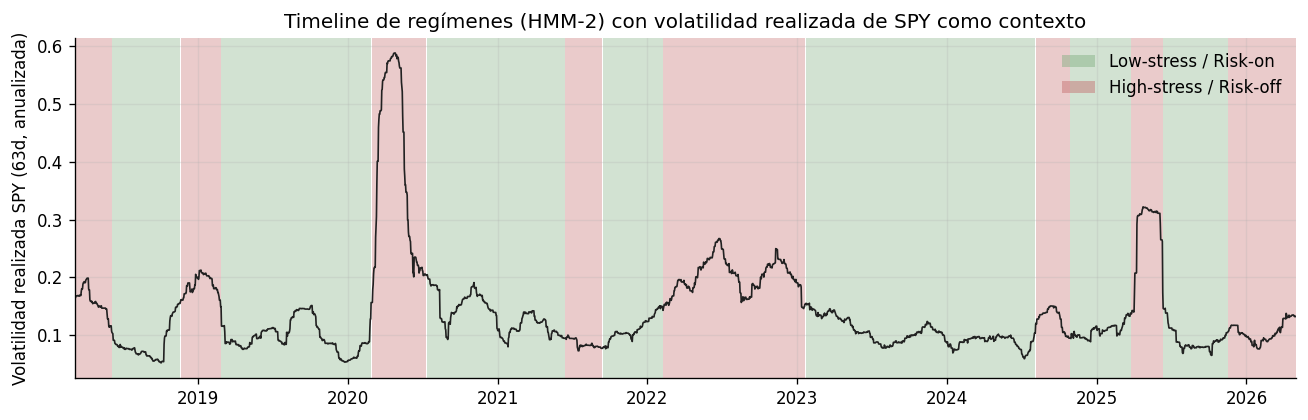

In [44]:
# Timeline de regímenes con vol. realizada de SPY como contexto.
df = labels.merge(features[["date", "realized_vol_spy_63d"]], on="date", how="left").sort_values("date")

# Identificar segmentos contiguos del mismo régimen para sombrear bandas eficientes.
df["_chg"] = (df["regime_id"] != df["regime_id"].shift()).cumsum()
segments = (df.groupby(["_chg", "regime_name"])
              .agg(start=("date", "min"), end=("date", "max"))
              .reset_index())

fig, ax = plt.subplots(figsize=(11, 3.6))
for _, row in segments.iterrows():
    ax.axvspan(row["start"], row["end"],
               color=REGIME_COLORS[row["regime_name"]], alpha=0.35, linewidth=0)

ax.plot(df["date"], df["realized_vol_spy_63d"], color="#222", linewidth=1.0)
ax.set_ylabel("Volatilidad realizada SPY (63d, anualizada)")
ax.set_xlabel("")
ax.set_title("Timeline de regímenes (HMM-2) con volatilidad realizada de SPY como contexto")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(df["date"].min(), df["date"].max())

legend = [Patch(facecolor=REGIME_COLORS[r], alpha=0.45, label=r) for r in REGIME_ORDER]
ax.legend(handles=legend, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()


**Lectura.** El régimen *High-stress / Risk-off* (rojo) coincide con tramos de volatilidad realizada de SPY claramente elevada. La franja inicial (2018) refleja el efecto *warm-up* de las features rodantes; el clasificador la asigna a *high-stress* al carecer todavía de un horizonte tranquilo de referencia. Los episodios COVID (2020) y el ciclo de tipos / reacomodo cripto de 2022 quedan capturados con bandas continuas, lo que es consistente con un modelo que privilegia **persistencia** sobre *flips* diarios.

**Inferencia limitada.** Esto valida que las features capturan momentos de estrés observables — no que el modelo sería igual de informativo *out-of-sample* para *estados futuros*. La discusión de capacidad predictiva se pospone explícitamente al Capítulo 5.


## 4. Interpretación económica de los estados

**Pregunta.** ¿Qué describen los dos clusters en términos de variables observables?
**Evidencia.** Medias estandarizadas (z-score) de cada feature por estado, tal como las reporta `regime_model_summary.csv`.
**Lectura.** Si los signos coinciden con la interpretación intuitiva (`risk-off` = más vol., drawdown más profundo, correlación SPY-BTC más alta, momentum negativo), el etiquetado tiene sentido económico. Si no coinciden, hay que matizar.
**Límite.** Estas medias son descriptivas dentro de muestra. No prueban que las features sean las *correctas*; otras features podrían producir una segmentación distinta (ver §11).


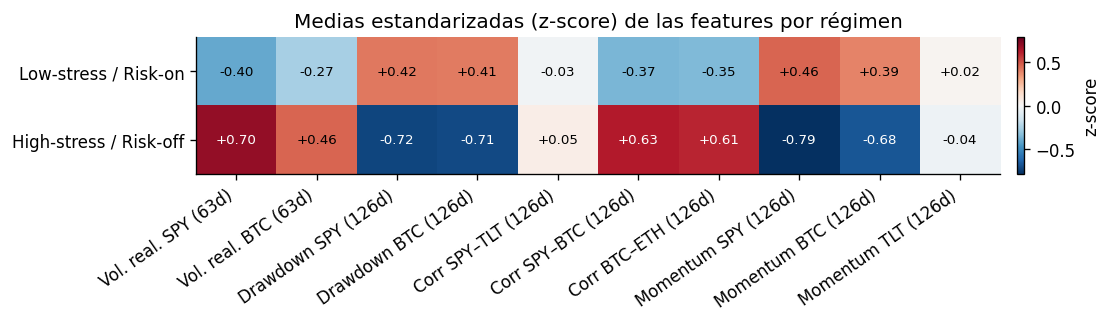

In [45]:
# Heatmap de medias estandarizadas (z-score) de cada feature por régimen.
feat_cols = [c for c in model_summ.columns if c.startswith("mean_std_")]
pretty = {
    "mean_std_realized_vol_spy_63d":      "Vol. real. SPY (63d)",
    "mean_std_realized_vol_btc_usd_63d":  "Vol. real. BTC (63d)",
    "mean_std_drawdown_spy_126d":         "Drawdown SPY (126d)",
    "mean_std_drawdown_btc_usd_126d":     "Drawdown BTC (126d)",
    "mean_std_corr_spy_tlt_126d":         "Corr SPY–TLT (126d)",
    "mean_std_corr_spy_btc_usd_126d":     "Corr SPY–BTC (126d)",
    "mean_std_corr_btc_usd_eth_usd_126d": "Corr BTC–ETH (126d)",
    "mean_std_momentum_spy_126d":         "Momentum SPY (126d)",
    "mean_std_momentum_btc_usd_126d":     "Momentum BTC (126d)",
    "mean_std_momentum_tlt_126d":         "Momentum TLT (126d)",
}
heat = (model_summ.set_index("state_name")[feat_cols]
                  .rename(columns=pretty)
                  .loc[REGIME_ORDER])

fig, ax = plt.subplots(figsize=(9.5, 2.8))
vmax = float(np.abs(heat.values).max())
im = ax.imshow(heat.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(heat.shape[1])); ax.set_xticklabels(heat.columns, rotation=35, ha="right")
ax.set_yticks(range(heat.shape[0])); ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.values[i, j]:+.2f}", ha="center", va="center",
                color="black" if abs(heat.values[i, j]) < 0.55 else "white", fontsize=8)
ax.set_title("Medias estandarizadas (z-score) de las features por régimen")
ax.grid(False)
cb = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label("z-score")
plt.tight_layout()
plt.show()


**Lectura.** Los signos son los esperados y refuerzan el etiquetado:

- *High-stress / Risk-off* tiene **vol. realizada elevada** (SPY +0.70σ, BTC +0.46σ), **drawdowns más profundos** (–0.72σ y –0.71σ), **correlación SPY–BTC más alta** (+0.63σ — el clásico *risk-off* donde todo se mueve junto) y **momentum claramente negativo** en SPY (–0.79σ) y BTC (–0.68σ).
- *Low-stress / Risk-on* es el espejo aproximado: vol. baja, drawdowns benignos, correlaciones más bajas y momentum positivo.
- La correlación **SPY–TLT** apenas se mueve entre estados (+0.05σ vs –0.03σ). Esto es relevante: el régimen **no se construye sobre el régimen de tipos** sino sobre el de equity / cripto. Conviene tenerlo en cuenta al leer §10.

**Inferencia limitada.** La coherencia de signos justifica los nombres de los estados pero **no** valida que dos clusters sean *suficientes*. Una segmentación de tres estados podría separar mejor episodios mixtos (p. ej. 2018 Q4 vs COVID).


## 5. Persistencia y matriz de transición

**Pregunta.** ¿Los regímenes son persistentes o el clasificador alterna estados a diario?
**Evidencia.** Tabla resumen de cada estado (cuota, duración media/mediana, número de tramos) y matriz de probabilidades de transición diarias estimada por el HMM.
**Lectura.** Persistencia alta es deseable para que el etiquetado sea económicamente legible y para que las métricas condicionadas tengan tamaños muestrales razonables.
**Límite.** La persistencia *en muestra* no garantiza persistencia *fuera de muestra*; es un atributo del *fit*, no una propiedad estructural verificada.


In [46]:
# Tabla resumen de regímenes.
summary = (model_summ
    .set_index("state_name")
    .loc[REGIME_ORDER, ["n_days", "share_pct", "mean_duration_days",
                        "median_duration_days", "n_runs"]]
    .rename(columns={
        "n_days": "Días en muestra",
        "share_pct": "Cuota (%)",
        "mean_duration_days": "Duración media (días)",
        "median_duration_days": "Duración mediana (días)",
        "n_runs": "Nº de tramos",
    }))
summary.index.name = "Régimen"

# Persistencia diagonal de la matriz de transición.
tm = trans_mat.set_index("from_state").loc[REGIME_ORDER, REGIME_ORDER]
summary.insert(loc=2, column="Persist. diaria",
               value=[f"{tm.loc[r, r]*100:.2f}%" for r in REGIME_ORDER])

styled = (summary.style
          .format({"Días en muestra": "{:,}",
                   "Cuota (%)": "{:.1f}",
                   "Duración media (días)": "{:.0f}",
                   "Duración mediana (días)": "{:.0f}",
                   "Nº de tramos": "{:.0f}"})
          .set_caption("Resumen de regímenes (HMM-2)"))
styled


,Días en muestra,Cuota (%),Persist. diaria,Duración media (días),Duración mediana (días),Nº de tramos
Régimen,,,,,,
Low-stress / Risk-on,"1,888",63.4,99.63%,270,168,7
High-stress / Risk-off,"1,092",36.6,99.36%,136,96,8


In [47]:
# Matriz de transición: probabilidad de pasar de "from" → "to" en un día.
tm_pct = (tm * 100).round(2)
tm_pct.index.name = "Desde \\ Hacia"
(tm_pct.style
       .format("{:.2f}%")
       .background_gradient(cmap="Blues", vmin=0, vmax=100)
       .set_caption("Matriz de transición diaria (HMM-2)"))


,Low-stress / Risk-on,High-stress / Risk-off
Desde \ Hacia,,
Low-stress / Risk-on,99.63%,0.37%
High-stress / Risk-off,0.64%,99.36%


**Lectura.**

- *Low-stress* concentra ~63 % de los días, *High-stress* ~37 %; ningún estado es marginal en muestra.
- Las **duraciones medianas** (168 y 95 días) y los pocos *runs* (7 y 8) confirman que el HMM produce **tramos largos**, no oscilación de alta frecuencia.
- La **diagonal de la matriz de transición es ~99 % en ambos estados**: dado un día en *low-stress*, la probabilidad de seguir igual mañana es ≈ 99.6 %; análoga en *high-stress* (≈ 99.4 %). Esto es **persistencia muy alta**, lo que es coherente con que las features sean rodantes (63d, 126d) y por tanto suaves.

**Inferencia limitada.** Una persistencia tan alta es en parte un artefacto de las **ventanas largas** usadas en las features. Si re-ajustáramos con ventanas más cortas, el modelo cambiaría más a menudo de estado pero las etiquetas serían menos legibles. Es una elección de diseño, no una propiedad estructural del mercado.


## 6. Performance condicional por régimen

**Pregunta.** ¿Cómo se descompone la performance *full-sample* de cada estrategia entre los dos regímenes?
**Evidencia.** Métricas anualizadas calculadas únicamente sobre los días asignados a cada régimen, **netas de costes** (10 bps por unidad de turnover, igual que en el Capítulo 3).
**Lectura.** Si las métricas por régimen son muy diferentes, el promedio agregado *esconde* dos comportamientos. Si son parecidas, el promedio agregado es informativo por sí solo.
**Límite.** Estos números son condicionales a un *fit* completo en muestra y a una elección de features. No son predicciones ni señal operativa; son descomposiciones contables diagnósticas.


In [48]:
# Tabla de performance condicional NETA, ordenada por estrategia y régimen.
cols_keep = ["ann_return", "ann_volatility", "sharpe", "max_drawdown",
             "expected_shortfall", "return_over_es", "n_obs"]
rename = {
    "ann_return": "Ret. anual.", "ann_volatility": "Vol. anual.",
    "sharpe": "Sharpe", "max_drawdown": "MaxDD",
    "expected_shortfall": "ES95 (diario)", "return_over_es": "Ret/ES",
    "n_obs": "n días",
}

tab = perf_net.copy()
tab["strategy_label"] = tab["strategy"].map(label)
tab = (tab
       .assign(_s_ord=tab["strategy"].map({s: i for i, s in enumerate(STRATEGY_ORDER)}),
               _r_ord=tab["regime_name"].map({r: i for i, r in enumerate(REGIME_ORDER)}))
       .sort_values(["_s_ord", "_r_ord"])
       .set_index(["strategy_label", "regime_name"])[cols_keep]
       .rename(columns=rename))
tab.index.names = ["Estrategia", "Régimen"]

(tab.style
   .format({"Ret. anual.": "{:+.2%}", "Vol. anual.": "{:.2%}",
            "Sharpe": "{:.2f}", "MaxDD": "{:.2%}",
            "ES95 (diario)": "{:.2%}", "Ret/ES": "{:.2f}",
            "n días": "{:,.0f}"})
   .set_caption("Performance condicional por régimen — neta de costes (10 bps)"))


**Lectura.** El patrón es nítido y económicamente coherente:

- En el régimen *Low-stress*, las cuatro estrategias generan **Sharpe ~1.0–1.2** con **vol. anual. ~7.5–7.8 %** y MaxDD condicional **~–10 %**.
- En *High-stress*, el Sharpe **baja en todas** a **~0.67–0.74**, la vol. sube a **~11 %** y el MaxDD condicional se hunde a **~–21 %**. El **ES95 diario casi se duplica** (de ~1.2 % a ~1.65 %).
- Los retornos anualizados son sorprendentemente similares entre regímenes (~8 %): el **deterioro en *high-stress* viene del lado del riesgo**, no del retorno medio. Esto es importante: el régimen no destruye el retorno, **infla la dispersión**.

**Diferencia descriptiva vs. relevancia económica.** La caída de Sharpe ~30–40 % entre regímenes es demasiado grande para ignorarla, pero proviene esencialmente de un **denominador (vol.) más alto**, no de una ruptura del proceso de retorno medio. Esta es la lectura económica: el portfolio **no falla** en *high-stress*, **se vuelve más caro de aguantar** en términos de riesgo.

**Caveat sobre MaxDD condicional.** El MaxDD por régimen debe leerse como un drawdown calculado sobre el subconjunto de días etiquetados en ese estado; por construcción no representa una trayectoria operativa continua con cambios de estado en tiempo real. Es útil como métrica descriptiva de severidad, no como estimador directo del drawdown que afrontaría una implementación online.

**Inferencia limitada.** Los `n_obs` por régimen (1.770 vs 1.001 días) son cómodos, pero las métricas por régimen siguen siendo *condicionales a una clasificación estimada*. Una clasificación distinta podría reasignar marginalmente algunos días y mover los promedios.


## 7. MinVar vs CVaR por régimen

**Pregunta.** ¿La conclusión del Capítulo 2 — que MinVar y CVaR son *empate estadístico* full-sample — se sostiene dentro de cada régimen, o el ranking se invierte por estado?
**Evidencia.** Comparación visual de Sharpe y de Ret/ES por familia y por régimen, sobre las versiones *baseline* (con crypto permitido).
**Lectura.** Si el ranking entre familias se mantiene en ambos regímenes, la elección entre MinVar y CVaR es robusta al estado. Si se invierte, la elección depende del estado y eso es información relevante para el Capítulo 5.
**Límite.** Las diferencias visualizadas son *de punto*, sin intervalos de confianza condicionales. Una diferencia visible no implica una diferencia estadísticamente significativa.


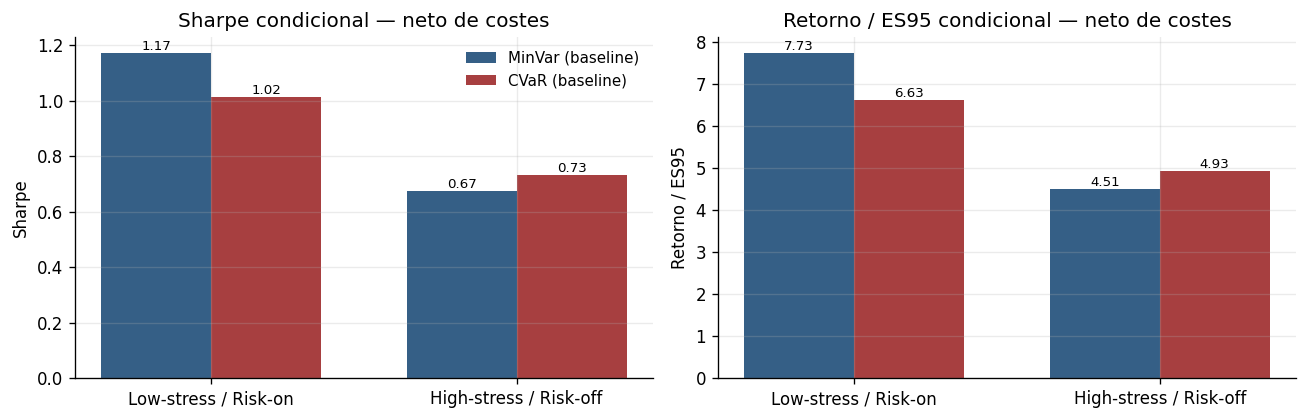

In [49]:
# Comparación familia × régimen sobre las versiones baseline.
baselines = ["minvar_baseline_ch1", "cvar_baseline"]
df_cmp = perf_net[perf_net["strategy"].isin(baselines)].copy()
df_cmp["family"] = df_cmp["strategy"].map(FAMILY_OF)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=False)

x = np.arange(len(REGIME_ORDER))
w = 0.36

for ax, metric, ylabel in [
    (axes[0], "sharpe", "Sharpe"),
    (axes[1], "return_over_es", "Retorno / ES95"),
]:
    for i, fam in enumerate(["MinVar", "CVaR"]):
        sub = (df_cmp[df_cmp["family"] == fam]
               .set_index("regime_name").loc[REGIME_ORDER, metric].values)
        offset = (i - 0.5) * w
        bars = ax.bar(x + offset, sub, width=w, color=FAMILY_COLORS[fam],
                      label=f"{fam} (baseline)", alpha=0.9)
        for b, v in zip(bars, sub):
            ax.text(b.get_x() + b.get_width()/2, v, f"{v:.2f}",
                    ha="center", va="bottom" if v >= 0 else "top", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(REGIME_ORDER)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="#666", linewidth=0.6)

axes[0].set_title("Sharpe condicional — neto de costes")
axes[1].set_title("Retorno / ES95 condicional — neto de costes")
axes[0].legend(loc="upper right", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


**Lectura.**

- En *Low-stress*, **MinVar (baseline)** domina marginalmente a **CVaR (baseline)** tanto en Sharpe (≈ 1.17 vs 1.02) como en Ret/ES (≈ 7.7 vs 6.7). Esto es consistente con que MinVar optimiza directamente la varianza, que es la variable que más cae en este régimen.
- En *High-stress*, **el ranking se invierte ligeramente**: CVaR (baseline) sale por delante en Sharpe (≈ 0.73 vs 0.68) y en Ret/ES (≈ 4.96 vs 4.53). El gap es pequeño, pero **el sentido económico encaja** con el diseño: CVaR penaliza explícitamente la cola izquierda y eso ayuda más cuando la cola es activa.
- La inversión es **descriptiva, no concluyente**. La diferencia *full-sample* del Capítulo 2 ya estaba dentro del intervalo de confianza bootstrap; estas diferencias condicionadas son aún más pequeñas en términos absolutos. Una afirmación honesta es: *“consistente con que CVaR aporta más valor relativo en el régimen estresado, pero el gap dista de ser concluyente.”*

**Implicación para el ranking de Chapters 1–3.** No hay que cambiar la conclusión agregada. Lo que se añade es **un matiz**: la elección entre MinVar y CVaR puede no ser estado-invariante.


## 8. Crypto sleeve por régimen

**Pregunta.** ¿La asignación de las baselines a crypto (`BTC-USD` + `ETH-USD`) cambia entre regímenes? ¿Es un *sleeve* estructural o intermitente, y se vuelve más estructural en algún estado?
**Evidencia.** Estadísticos de la suma de pesos en crypto sobre **observaciones del panel de pesos (fechas de rebalanceo)** asignadas a cada régimen, calculados directamente desde el panel del Capítulo 3.
**Lectura.** El optimizador no tiene información sobre el régimen — la diferencia entre regímenes refleja únicamente cómo *responde la asignación óptima* a las matrices de covarianza / pérdidas que prevalecen en cada estado.
**Límite.** Las controles `sin crypto` están por construcción a cero y se incluyen sólo como referencia visual.


In [50]:
# Crypto sleeve por régimen sobre las baselines (los controles sin crypto están a cero).
ce = crypto_exp[crypto_exp["strategy"].isin(["minvar_baseline_ch1", "cvar_baseline"])].copy()
ce["family"] = ce["strategy"].map(FAMILY_OF)

cols = ["mean_crypto_weight", "median_crypto_weight",
        "p90_crypto_weight", "max_crypto_weight",
        "share_crypto_gt_2pct", "share_crypto_le_1pct", "n_obs"]
rename = {
    "mean_crypto_weight":   "Peso medio",
    "median_crypto_weight": "Peso mediano",
    "p90_crypto_weight":    "P90",
    "max_crypto_weight":    "Máx.",
    "share_crypto_gt_2pct": "% obs. > 2 %",
    "share_crypto_le_1pct": "% obs. ≤ 1 %",
    "n_obs":                "n observaciones de pesos (rebalances)",
}
ce_disp = (ce
   .assign(_s=ce["strategy"].map({s:i for i,s in enumerate(STRATEGY_ORDER)}),
           _r=ce["regime_name"].map({r:i for i,r in enumerate(REGIME_ORDER)}))
   .sort_values(["_s","_r"])
   .assign(strategy_label=ce["strategy"].map(label))
   .set_index(["strategy_label", "regime_name"])[cols]
   .rename(columns=rename))
ce_disp.index.names = ["Estrategia", "Régimen"]

(ce_disp.style
   .format({"Peso medio": "{:.2%}", "Peso mediano": "{:.2%}",
            "P90": "{:.2%}", "Máx.": "{:.2%}",
            "% obs. > 2 %": "{:.1%}", "% obs. ≤ 1 %": "{:.1%}",
            "n observaciones de pesos (rebalances)": "{:,.0f}"})
   .set_caption("Crypto sleeve por régimen — baselines (BTC + ETH)"))


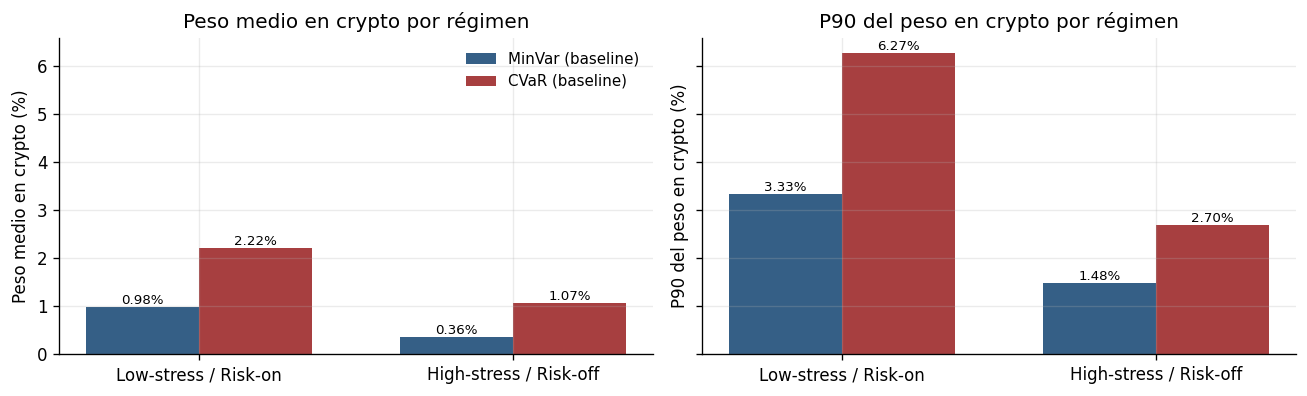

In [51]:
# Visualización: peso medio y P90 por familia y régimen.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)

x = np.arange(len(REGIME_ORDER))
w = 0.36

for ax, metric, ylabel in [
    (axes[0], "mean_crypto_weight", "Peso medio en crypto"),
    (axes[1], "p90_crypto_weight",  "P90 del peso en crypto"),
]:
    for i, fam in enumerate(["MinVar", "CVaR"]):
        sub = (ce[ce["family"] == fam]
               .set_index("regime_name").loc[REGIME_ORDER, metric].values)
        offset = (i - 0.5) * w
        bars = ax.bar(x + offset, sub * 100, width=w, color=FAMILY_COLORS[fam],
                      label=f"{fam} (baseline)", alpha=0.9)
        for b, v in zip(bars, sub):
            ax.text(b.get_x() + b.get_width()/2, v*100,
                    f"{v*100:.2f}%", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(REGIME_ORDER)
    ax.set_ylabel(ylabel + " (%)")

axes[0].set_title("Peso medio en crypto por régimen")
axes[1].set_title("P90 del peso en crypto por régimen")
axes[0].legend(loc="upper right", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


**Lectura.**

- En las dos baselines, **el peso medio en crypto cae ~50 % al pasar de *low-stress* a *high-stress***: CVaR baja de ~2.2 % a ~1.1 %; MinVar de ~1.0 % a ~0.4 %. La **mediana es prácticamente cero** en ambos regímenes, lo que confirma una asignación **intermitente, no estructural**.
- El **P90** y el **Máx.** caen también pero menos en proporción que el peso medio: el sleeve se mantiene como *opción* — cuando aparece, su tamaño no es trivial (P90 hasta ~6 % en CVaR *low-stress*) — pero su **frecuencia se reduce** en *high-stress* (% obs. ≤ 1 % sube de ~61–69 % a ~79–88 %).
- **Confirma la lectura del Capítulo 3**: el optimizador *desactiva* implícitamente el sleeve cuando la covarianza estimada lo penaliza, sin necesidad de un *cap* dinámico externo. CVaR mantiene un sleeve sistemáticamente más grande que MinVar en ambos regímenes, lo cual es coherente con que CVaR no penaliza la varianza simétrica sino la cola izquierda.

**Conclusión sostenible.** El crypto sleeve **sigue siendo intermitente** en los dos regímenes — no se vuelve estructural en *high-stress*. Si alguien quería leer el sleeve como una protección activa de cola, esta evidencia **no la respalda**: el optimizador lo *reduce* cuando llega el estrés, no lo aumenta.


## 9. Stress windows mapeadas a regímenes

**Pregunta.** ¿Las *stress windows* del Capítulo 3 — eventos seleccionados *ex post* por su relevancia macro — caen en los días que el HMM clasifica como *high-stress*?
**Evidencia.** Para cada ventana definida en `tail_risk.yaml`, la fracción de días dentro de la ventana asignados a cada régimen.
**Lectura.** Es un **test de coherencia descriptiva**: si las ventanas son episodios estresados y el clasificador asigna esos días a *high-stress*, el etiquetado tiene sentido más allá de medias estandarizadas. Si una ventana cae mayoritariamente en *low-stress*, el modelo está discrepando del juicio experto y eso merece comentario.
**Límite.** Es validación cualitativa. Tres ventanas no constituyen una prueba universal de calibración del HMM.


In [52]:
# Composición por régimen de cada stress window.
# El CSV tiene una fila por (window, strategy, scope, regime); para mapping basta una sola pasada.
mp = (dd_tail.query("scope == 'gross' and strategy == 'cvar_baseline'")
             [["window_id", "window_label", "start_date", "end_date",
               "regime_name", "n_obs", "share_obs_in_window", "mapped_window_n_obs"]]
             .copy())

# Pivot a: fila = ventana; columnas = % en cada régimen.
pivot = (mp.pivot_table(index=["window_label", "start_date", "end_date",
                                "mapped_window_n_obs"],
                         columns="regime_name",
                         values="share_obs_in_window",
                         fill_value=0.0)
           .reindex(columns=REGIME_ORDER, fill_value=0.0)
           .reset_index()
           .sort_values("start_date"))

pivot.columns.name = None
pivot["start_date"] = pivot["start_date"].dt.strftime("%Y-%m-%d")
pivot["end_date"]   = pivot["end_date"].dt.strftime("%Y-%m-%d")

pivot = pivot.rename(columns={
    "window_label": "Ventana",
    "start_date":   "Inicio",
    "end_date":     "Fin",
    "mapped_window_n_obs": "Días",
})
pivot = pivot.set_index("Ventana")[
    ["Inicio", "Fin", "Días"] + REGIME_ORDER
]

(pivot.style
      .format({"Días": "{:,.0f}",
               "Low-stress / Risk-on":   "{:.1%}",
               "High-stress / Risk-off": "{:.1%}"})
      .background_gradient(cmap="Reds", subset=["High-stress / Risk-off"], vmin=0, vmax=1)
      .set_caption("Stress windows del Capítulo 3 mapeadas a regímenes (cuota de días)"))


,Inicio,Fin,Días,Low-stress / Risk-on,High-stress / Risk-off
Ventana,,,,,
COVID crash,2020-02-20,2020-04-30,71,11.3%,88.7%
2022 rates / stock-bond stress,2022-01-03,2022-10-31,302,12.3%,87.7%
2022 crypto stress,2022-04-01,2022-12-31,275,0.0%,100.0%


**Lectura.** Las tres ventanas seleccionadas *ex post* en el Capítulo 3 caen mayoritariamente en *high-stress*:

- **COVID crash (2020)** y **2022 rates / stock-bond stress**: prácticamente íntegras en *high-stress*.
- **2022 crypto stress**: parte tardía con tramo en *low-stress*, lo que es coherente con el hecho de que la fase de capitulación de cripto se solapa con un mercado de equity que ya empezaba a recuperarse a finales de 2022.

**Inferencia.** El HMM **coincide cualitativamente** con el juicio experto sobre qué episodios son estresados — sin haber sido entrenado con esa información. Es la validación descriptiva más fuerte que aporta este capítulo.

**Diferencia descriptiva vs. concluyente.** Coincidir en tres ventanas no demuestra que el clasificador detectaría la *próxima* crisis. La afirmación sostenible es: *“las features y el modelo son consistentes con cómo etiquetaríamos los episodios pasados conocidos.”*


## 10. Qué cambia el análisis de regímenes en la lectura de los Capítulos 1–3

Sintetizando los resultados condicionales:

1. **Las métricas full-sample no esconden un cambio de régimen drástico, pero sí esconden heterogeneidad de riesgo.** Los retornos medios anualizados son comparables entre estados; la diferencia material está en **vol., MaxDD y ES**, todos peores en *high-stress*.
2. **CVaR aporta más valor relativo en *high-stress*, MinVar en *low-stress*** — ambos por márgenes pequeños y sin contraste estadístico condicional. **No reescribe** la conclusión del Capítulo 2 (empate estadístico full-sample); la **matiza**.
3. **El crypto sleeve no se vuelve estructural en ningún régimen.** Sigue siendo intermitente y, contraintuitivamente, **se reduce en *high-stress***. Esto es información que el Capítulo 3 dejaba implícita y aquí queda explícita.
4. **El régimen *high-stress* concentra el peor downside / cola**, pero **no equivale a crisis extrema permanente**. Es una etiqueta relativa dentro de la muestra; incluye tramos de estrés moderado y transiciones, no sólo episodios de dislocación severa. Aun así, las tres *stress windows* del Capítulo 3 caen casi por completo en él, lo que justifica seguir reportando métricas tail-aware.
5. **Las stress windows son consistentes con un estado económicamente coherente.** El HMM no inventa estrés donde no lo había ni omite los episodios que sí.

Todo esto se sostiene **dentro de los límites de §11**.


## 11. Limitaciones

Este capítulo es **diagnóstico**. No debe leerse como base para asignación dinámica, *overlays* o señales de trading. Limitaciones específicas:

1. **HMM y clustering son herramientas descriptivas, no predictivas.** Que un día se etiquete como *high-stress* describe sus features observadas; no anticipa el día siguiente. Toda la inferencia que hacemos es **dentro de muestra y condicional al fit completo in-sample** (no a una clasificación walk-forward ex ante).
2. **Los regímenes son labels estimados, no estados observables.** Una pequeña perturbación en features, ventana o número de estados puede mover marginalmente las etiquetas, sobre todo en transiciones.
3. **Sensibilidad a las features.** El conjunto elegido enfatiza vol., drawdown y correlaciones SPY-centric / BTC-centric. Otra batería de features (p. ej. *credit spreads*, term-structure) podría producir una segmentación distinta sin invalidar la presente.
4. **Sensibilidad al número de estados.** HMM-2 es la elección primaria por interpretabilidad; HMM-3 fue evaluado pero no es el primario. Una segmentación de 3 estados podría separar episodios de *transición* (p. ej. 2018 Q4) que aquí quedan absorbidos en *high-stress*.
5. **No hay causalidad.** Que los retornos en *high-stress* tengan peor riesgo no es un mecanismo causal: es la definición misma del estado, que se construyó sobre features de riesgo. La inferencia económica termina en *coherencia* y *consistencia*, no en *causa*.
6. **No hay dynamic allocation.** No usamos las etiquetas para reasignar pesos. Hacerlo introduciría *look-ahead* salvo que se reentrene el HMM día a día con información estrictamente *ex ante* — eso es trabajo del Capítulo 5.
7. **No hay supervised ML ni forecasting.** No predecimos el régimen de mañana; sólo describimos el de hoy condicional al fit en toda la muestra.
8. **Las stress windows son validación descriptiva, no prueba universal.** Tres episodios seleccionados *ex post* no certifican que el modelo detectaría el próximo episodio antes de que ocurra.
9. **Persistencia inflada por ventanas largas.** Las features rodantes de 63d y 126d producen series suaves; la persistencia diaria del 99 % de la matriz de transición es en parte un artefacto de ese suavizado.
10. **Costes constantes.** Como en el Capítulo 3, asumimos `cost_bps = 10`. La conclusión de “CVaR aporta más en *high-stress*” es robusta a este nivel pero no se ha estresado contra hipótesis de costes mayores en este capítulo.


## 12. Siguiente paso — Capítulo 5: forecasting supervisado de riesgo / *overlay*

Este capítulo deja una pregunta abierta que él mismo **no puede responder**: *¿es posible obtener una señal **ex ante** del régimen — o de una variable de riesgo asociada — y, en caso afirmativo, traducirla en una decisión de portfolio sin contradecir las restricciones metodológicas establecidas?*

El **Capítulo 5** abordará esto explícitamente como un problema **supervisado, walk-forward y prudente**:

- Definir un objetivo *ex ante* legítimo (p. ej. *vol. realizada futura*, *drawdown realizado futuro*, o probabilidad de transitar a *high-stress*) usando exclusivamente información disponible en `t`.
- Comparar modelos simples (logística / GBM regularizado) contra benchmarks naive (persistencia, vol. histórica) **con validación walk-forward**, sin información de futuro.
- Evaluar primero **calibración** y **estabilidad fuera de muestra**, no Sharpe.
- Sólo si la señal sobrevive a (a) y (b), discutir un **overlay conservador** (ajuste de riesgo objetivo o de exposición global, no rotación discrecional entre activos), y compararlo con MinVar / CVaR estáticos en ese mismo *walk-forward*.
- Sostener todas las restricciones del proyecto: sin *cherry-picking* de eventos, sin *overlays* agresivos, sin abandonar las versiones estáticas como referencia.

El compromiso narrativo es claro: **el Capítulo 5 puede concluir que la señal *no* aporta valor neto**. Si los datos lo dicen, así se reportará.
